<a href="https://colab.research.google.com/github/Tsanami/HSE_DL_2026/blob/HW7/HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import torch
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import math
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import torch.optim as optim
from tqdm import tqdm
import math
import random
import logging
from torch.utils.data import DataLoader, ConcatDataset, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence
import pickle
import ast
from copy import deepcopy
from huggingface_hub import hf_hub_download
from measures import uar, mf1, acc_func, ccc

import time
import math
from types import SimpleNamespace
from sklearn.metrics import accuracy_score, classification_report

import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
def transform_matrix(matrix):
    threshold1 = 1 - 1/7
    threshold2 = 1/7
    mask1 = matrix[:, 0] >= threshold1
    result = np.zeros_like(matrix[:, 1:])
    transformed = (matrix[:, 1:] >= threshold2).astype(int)
    result[~mask1] = transformed[~mask1]
    return result
def process_predictions(pred_emo):
    pred_emo = torch.nn.functional.softmax(pred_emo, dim=1).cpu().detach().numpy()
    pred_emo = transform_matrix(pred_emo).tolist()
    return pred_emo

# Эксперименты

In [14]:
# ==========================================
# Метрики (из measures.py + пользовательские)
# ==========================================

def mf1(targets, predicts, return_scores=False):
    targets = np.array(targets)
    predicts = np.array(predicts)
    f1_macro_scores = []
    for i in range(predicts.shape[1]):
        cr = classification_report(targets[:, i], predicts[:, i], output_dict=True, zero_division=0)
        f1_macro_scores.append(cr['macro avg']['f1-score'])
    if return_scores:
        return np.mean(f1_macro_scores), f1_macro_scores
    return np.mean(f1_macro_scores)

def mean_weighted_accuracy(targets, predicts):
    """Средняя точность по каждому из классов (аналог UAR, но для accuracy)"""
    targets = np.array(targets)
    predicts = np.array(predicts)
    acc_scores = []
    for i in range(predicts.shape[1]):
        acc_scores.append(accuracy_score(targets[:, i], predicts[:, i]))
    return np.mean(acc_scores)

def transform_matrix(matrix):
    threshold1 = 1 - 1/7
    threshold2 = 1/7
    mask1 = matrix[:, 0] >= threshold1
    result = np.zeros_like(matrix[:, 1:])
    transformed = (matrix[:, 1:] >= threshold2).astype(int)
    result[~mask1] = transformed[~mask1]
    return result

def uar(targets, predicts, return_scores=False):
    targets = np.array(targets)
    predicts = np.array(predicts)
    uar_scores = []
    for i in range(predicts.shape[1]):
        from sklearn.metrics import classification_report
        cr = classification_report(targets[:, i], predicts[:, i], output_dict=True, zero_division=0)
        uar_scores.append(cr['macro avg']['recall'])
    if return_scores:
        return np.mean(uar_scores), uar_scores
    return np.mean(uar_scores)

def predict_emotions(logits):
    """Реализация логики с порогами из transform_matrix"""
    probs = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
    threshold1 = 1 - 1/7
    threshold2 = 1/7
    mask1 = probs[:, 0] >= threshold1
    result = np.zeros_like(probs[:, 1:])
    transformed = (probs[:, 1:] >= threshold2).astype(int)
    result[~mask1] = transformed[~mask1]
    return result

# Механизмы Внимания

In [7]:
class StandardSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)
        self.to_out = nn.Linear(dim, dim)

    def forward(self, x, H=None, W=None):
        B, N, D = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: t.view(B, N, self.num_heads, self.head_dim).transpose(1, 2), qkv)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.to_out(out)

class VanillaLinearAttention(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.to_q = nn.Linear(dim, dim, bias=False)
        self.to_k = nn.Linear(dim, dim, bias=False)
        self.to_v = nn.Linear(dim, dim, bias=False)
        self.to_out = nn.Linear(dim, dim)

    def forward(self, x, H=None, W=None):
        B, N, D = x.shape
        q = F.relu(self.to_q(x)) + self.eps
        k = F.relu(self.to_k(x)) + self.eps
        v = self.to_v(x)
        kv = torch.einsum('b n d, b n e -> b d e', k, v)
        k_sum = k.sum(dim=1)
        num = torch.einsum('b n d, b d e -> b n e', q, kv)
        den = torch.einsum('b n d, b d -> b n', q, k_sum).unsqueeze(-1).clamp(min=self.eps)
        return self.to_out(num / den)

class MHLA1D(nn.Module):
    """MHLA адаптированный для 1D последовательностей (разбиение на чанки)"""
    def __init__(self, dim, num_heads_mhla=4, feature_map='relu', eps=1e-6):
        super().__init__()
        self.dim = dim
        self.M = num_heads_mhla
        self.eps = eps
        self.to_q = nn.Linear(dim, dim, bias=False)
        self.to_k = nn.Linear(dim, dim, bias=False)
        self.to_v = nn.Linear(dim, dim, bias=False)
        self.to_out = nn.Linear(dim, dim, bias=False)
        self.mixing_coeff = nn.Parameter(torch.randn(self.M, self.M) * 0.01)

    def feature_map_fn(self, x):
        return F.relu(x) + self.eps

    def forward(self, x, H=None, W=None):
        B, N, D = x.shape
        q = self.feature_map_fn(self.to_q(x))
        k = self.feature_map_fn(self.to_k(x))
        v = self.to_v(x)

        # 1D Chunking: разбиваем последовательность на M блоков
        chunk_size = N // self.M
        if chunk_size == 0: # Если последовательность короче M, используем обычный LA
            kv = torch.einsum('b n d, b n e -> b d e', k, v)
            k_sum = k.sum(dim=1)
            num = torch.einsum('b n d, b d e -> b n e', q, kv)
            den = torch.einsum('b n d, b d -> b n', q, k_sum).unsqueeze(-1).clamp(min=self.eps)
            return self.to_out(num / den)

        # Обрезаем до кратного M
        q_r = q[:, :chunk_size*self.M, :].view(B, self.M, chunk_size, D)
        k_r = k[:, :chunk_size*self.M, :].view(B, self.M, chunk_size, D)
        v_r = v[:, :chunk_size*self.M, :].view(B, self.M, chunk_size, D)

        # Локальные сводки
        kv_summary = torch.einsum('b m n d, b m n e -> b m d e', k_r, v_r)
        z_summary = k_r.sum(dim=2)

        # Mixing
        coeff = F.softmax(self.mixing_coeff, dim=-1)
        mixed_kv = torch.einsum('i m, b m d e -> b i d e', coeff, kv_summary)
        mixed_z = torch.einsum('i m, b m d -> b i d', coeff, z_summary)

        # Вычисление внимания
        numerator = torch.einsum('b i n d, b i d e -> b i n e', q_r, mixed_kv)
        denominator = torch.einsum('b i n d, b i d -> b i n', q_r, mixed_z).unsqueeze(-1).clamp(min=self.eps)

        out_r = (numerator / denominator).view(B, chunk_size*self.M, D)

        # Дополняем остаток токенов обычным LA (если N не делится на M)
        out = torch.zeros_like(x)
        out[:, :chunk_size*self.M, :] = out_r

        if N % self.M != 0:
            res_q = q[:, chunk_size*self.M:, :]
            kv_res = torch.einsum('b n d, b n e -> b d e', k, v)
            k_sum_res = k.sum(dim=1)
            num_res = torch.einsum('b n d, b d e -> b n e', res_q, kv_res)
            den_res = torch.einsum('b n d, b d -> b n', res_q, k_sum_res).unsqueeze(-1).clamp(min=self.eps)
            out[:, chunk_size*self.M:, :] = num_res / den_res

        return self.to_out(out)

In [8]:
# Обертка для ZeroS (интеграция предоставленного кода)
from zeros import ZeroSAttention # Предполагаем, что ваш файл называется zeros.py

class ZeroSWrapper(nn.Module):
    def __init__(self, dim, num_heads, block_size=512):
        super().__init__()
        config = SimpleNamespace(
            n_embd=dim, n_head=num_heads, bias=True, dropout=0.1,
            block_size=block_size, is_causal=False, # Для классификации эмоций обычно не каузально
            init_params=False, use_norm=True, use_associative=True, is_first_layer=False
        )
        self.attn = ZeroSAttention(config)

    def forward(self, x, H=None, W=None):
        return self.attn(x)

In [15]:
# ==========================================
# 3. Модель Трансформера
# ==========================================

class CustomTransformerLayer(nn.Module):
    def __init__(self, dim, attn_module, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = attn_module
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x

class EmotionTransformer(nn.Module):
    def __init__(self, input_dim_emotion=1024, hidden_dim=128, out_features=512,
                 num_transformer_heads=4, tr_layer_number=1, dropout=0.1, num_emotions=7,
                 attn_type='softmax', max_seq_len=100):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.emo_proj = nn.Sequential(
            nn.Linear(input_dim_emotion, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout)
        )

        self.positional_encoding = nn.Parameter(torch.zeros(1, 1000, hidden_dim))

        # Выбор механизма внимания
        if attn_type == 'softmax':
            attn_fn = lambda: StandardSelfAttention(hidden_dim, num_heads=num_transformer_heads)
        elif attn_type == 'linear':
            attn_fn = lambda: VanillaLinearAttention(hidden_dim)
        elif attn_type == 'mhla':
            attn_fn = lambda: MHLA1D(hidden_dim, num_heads_mhla=4)
        elif attn_type == 'zeros':
            attn_fn = lambda: ZeroSWrapper(hidden_dim, num_heads=num_transformer_heads, block_size=max_seq_len)
        else:
            raise ValueError(f"Unknown attn_type: {attn_type}")

        self.layers = nn.ModuleList([
            CustomTransformerLayer(hidden_dim, attn_fn(), dropout=dropout)
            for _ in range(tr_layer_number)
        ])

        self.emotion_fc_out = nn.Sequential(
            nn.Linear(hidden_dim, out_features),
            nn.LayerNorm(out_features),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(out_features, num_emotions)
        )

    def forward(self, emotion_input):
        B, T, _ = emotion_input.size()
        emo = self.emo_proj(emotion_input)
        emo = emo + self.positional_encoding[:, :T, :]

        for layer in self.layers:
            emo = layer(emo)

        out_emo = self.emotion_fc_out(emo.mean(dim=1))  # (B, num_emotions)
        return {"emotion_logits": out_emo}

In [29]:
def get_cmu_mosei_data(path, part='train'):
    if part in ['train', 'validation', 'test']:
        df = pd.read_csv(os.path.join(path, part + ".csv"))
    else:
        raise ValueError('Unknown part of train / dev / test')

    return df.text.values, np.dstack((df.Neutral.to_numpy(), df.Anger.to_numpy(), df.Disgust.to_numpy(), df.Fear.to_numpy(), df.Happiness.to_numpy(), df.Sadness.to_numpy(), df.Surprise.to_numpy()))

class DatasetEmotionAH(Dataset):
    def __init__(self, dataset='CMU-MOSEI', part='train', path='data', path_to_emb=None, model='bge-small'):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.dataset_name = dataset

        # 1. Загрузка сырых данных
        if dataset == 'CMU-MOSEI':
            texts, labels = get_cmu_mosei_data(path, part) # Предполагается, что функция определена ранее
            self.task_name = 'emotion'
        elif dataset == 'BAH':
            texts, labels = get_bah_data(path, part)       # Предполагается, что функция определена ранее
            self.task_name = 'uncertainty'
        else:
            raise ValueError('Unknown dataset (CMU-MOSEI / BAH)')

        self.x = texts
        self.y = labels[0]

        # 2. Извлечение или загрузка эмбеддингов
        if path_to_emb is None:
            if model == 'jina':
                model_name_hf = "jinaai/jina-embeddings-v3"
                self.feature_extractor_tokenizer = AutoTokenizer.from_pretrained(model_name_hf, trust_remote_code=True)
                self.feature_extractor_model = AutoModel.from_pretrained(model_name_hf, trust_remote_code=True).to(self.device)
            elif model == 'xlm-roberta-base':
                model_name_hf = 'xlm-roberta-base'
                self.feature_extractor_tokenizer = AutoTokenizer.from_pretrained(model_name_hf)
                self.feature_extractor_model = AutoModel.from_pretrained(model_name_hf).to(self.device)
            elif model == 'bge-small':
                model_name_hf = "BAAI/bge-small-en-v1.5"
                self.feature_extractor_tokenizer = AutoTokenizer.from_pretrained(model_name_hf)
                self.feature_extractor_model = AutoModel.from_pretrained(model_name_hf).to(self.device)
            else:
                raise ValueError('Unknown name of model')

            self.text_embedding = []

            # ВАЖНО: model.eval() чтобы не считались градиенты и dropout
            self.feature_extractor_model.eval()

            print(f"Extracting features for {dataset} ({part}) using {model}...")
            for t in tqdm(texts):
                encoded_input = self.feature_extractor_tokenizer(t, padding=True, truncation=True, max_length=128, return_tensors='pt').to(self.device)
                with torch.no_grad():
                    features = self.feature_extractor_model(**encoded_input).last_hidden_state.squeeze(0).cpu()
                self.text_embedding.append(features)

            # ==========================================
            # НОВЫЙ КОД: Сохранение эмбеддингов на диск
            # ==========================================
            save_dir = os.path.join(path, 'embeddings_cache')
            os.makedirs(save_dir, exist_ok=True)

            # Формируем понятное имя файла: например, BAH_train_bge-small_embeddings.pkl
            save_filename = f"{dataset}_{part}_{model}_embeddings.pkl"
            save_path = os.path.join(save_dir, save_filename)

            print(f"Saving extracted embeddings to {save_path}...")
            with open(save_path, 'wb') as f:
                pickle.dump(self.text_embedding, f)
            print("Embeddings saved successfully!")
            # ==========================================

        else:
            print(f"Loading embeddings from {path_to_emb}...")
            with open(path_to_emb, 'rb') as file:
                self.text_embedding = pickle.load(file)

        self.n_samples = len(texts)

    def __getitem__(self, index):
        # Обработка меток на лету
        if self.task_name == 'emotion':
            # Логика 7 классов (6 базовых + 1 нейтральность)
            label_tensor = torch.tensor(np.array(self.y[index]) > 0, dtype=torch.float32)
        else:
            # Логика BAH (0 или 1)
            label_tensor = torch.tensor(self.y[index], dtype=torch.long)

        return {
            "text": self.x[index],
            "text_embedding": self.text_embedding[index], # Тензор [seq_len, hidden_dim]
            "label": label_tensor,
            "task_name": self.task_name
        }

    def __len__(self):
        return self.n_samples


def custom_collate_fn(batch):
    """Собирает список образцов в единый батч."""
    batch = [x for x in batch if x is not None]
    if not batch:
        return None

    text = [b["text"] for b in batch]
    task_names = [b["task_name"] for b in batch]

    # Оставляем метки списком, чтобы не было ошибки несовпадения размерностей
    labels = [b["label"] for b in batch]

    # Собираем эмбеддинги
    text_embedding = [b["text_embedding"] for b in batch]
    text_tensor = pad_sequence(text_embedding, batch_first=True)

    # Переносим на GPU только сам батч
    text_tensor = text_tensor

    return {
        "text": text,
        "text_embedding": text_tensor,
        "label": labels,
        "task_name": task_names
    }

In [30]:
emo_test_dataset = dataset=DatasetEmotionAH(dataset='CMU-MOSEI', part='test', path='/content/', path_to_emb="/content/CMU-MOSEI_test_bge-small_embeddings.pkl")
emo_train_dataset = dataset=DatasetEmotionAH(dataset='CMU-MOSEI', part='train', path='/content/', path_to_emb='/content/CMU-MOSEI_train_bge-small_embeddings.pkl')
emo_val_dataset = dataset=DatasetEmotionAH(dataset='CMU-MOSEI', part='validation', path='/content/', path_to_emb='/content/CMU-MOSEI_validation_bge-small_embeddings.pkl')

emo_train_loader = DataLoader(emo_train_dataset, batch_size=32, shuffle=True,  collate_fn=custom_collate_fn, num_workers=4,
    pin_memory=True)
emo_val_loader   = DataLoader(emo_val_dataset,   batch_size=32, shuffle=False, collate_fn=custom_collate_fn, num_workers=4,
    pin_memory=True)
emo_test_loader  = DataLoader(emo_test_dataset,  batch_size=32, shuffle=False, collate_fn=custom_collate_fn)

emo_weights = torch.FloatTensor([5.890161, 7.534918, 11.228363, 27.722221, 1.3049748, 5.6189237, 26.639517]).to(device)

Loading embeddings from /content/CMU-MOSEI_test_bge-small_embeddings.pkl...
Loading embeddings from /content/CMU-MOSEI_train_bge-small_embeddings.pkl...
Loading embeddings from /content/CMU-MOSEI_validation_bge-small_embeddings.pkl...


# Цикл Обучения и Тестирования

In [31]:
def train_emo_one_epoch(model, optimizer, dataloader, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds, all_trues = [], []

    for batch in tqdm(dataloader, desc="Training EMO", leave=False):
        if batch is None: continue

        text_emb = batch["text_embedding"].to(device)            # [B, T, 384]
        labels   = torch.stack(batch["label"]).to(device).float() # [B, 7]

        optimizer.zero_grad()

        logits = model(emotion_input=text_emb)["emotion_logits"] # [B, 7]
        loss   = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

        predicted = predict_emotions(logits)
        all_preds.extend(predicted)
        all_trues.extend(labels[:, 1:].cpu().numpy())          # сравниваем только 6 классов

    preds_arr = np.array(all_preds)
    trues_arr = np.array(all_trues)
    acc = (preds_arr == trues_arr).mean()

    return {"loss": running_loss / len(dataloader), "acc": acc}

def eval_emo_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_trues = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating EMO", leave=False):
            if batch is None: continue

            text_emb = batch["text_embedding"].to(device)
            labels   = torch.stack(batch["label"]).to(device).float()

            logits = model(emotion_input=text_emb)["emotion_logits"]
            loss   = criterion(logits, labels)
            running_loss += loss.item()

            predicted = predict_emotions(logits)
            all_preds.extend(predicted)
            all_trues.extend(labels[:, 1:].cpu().numpy())

    preds_arr = np.array(all_preds)
    trues_arr = np.array(all_trues)

    acc = (preds_arr == trues_arr).mean()
    f1  = mf1(trues_arr, preds_arr)
    uar_score = uar(trues_arr, preds_arr)

    return {"loss": running_loss / len(dataloader), "acc": acc, "f1": f1, "uar": uar_score}

def run_experiment(attn_type, device, epochs=3, seq_len=50, batch_size=16):
    print(f"\n{'='*50}\nTraining with: {attn_type}\n{'='*50}")

    single_model_path = f"best_models/single_model_{attn_type}.pt"
    model = EmotionTransformer(input_dim_emotion=384, hidden_dim=256, out_features=256,
                 num_transformer_heads=4, tr_layer_number=3, dropout=0.0, num_emotions=7,
                               attn_type=attn_type, max_seq_len=seq_len).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

    scheduler_emo = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    criterion = nn.CrossEntropyLoss(weight=emo_weights)

    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(device)
        start_mem = torch.cuda.memory_allocated(device) / 1024**2

    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_uar': [], 'epoch_time': []}

    patience_counter = 0
    MAX_PATIENCE = 15
    best_f1 = -1.0

    for epoch in range(epochs):
        start_time = time.time()

        train_res = train_emo_one_epoch(model, optimizer, emo_train_loader, criterion, device)
        val_res = eval_emo_one_epoch(model, emo_val_loader, criterion, device)

        scheduler_emo.step(val_res["f1"])

        epoch_time = time.time() - start_time

        history['train_loss'].append(train_res['loss'])
        history['val_loss'].append(val_res['loss'])
        history['val_f1'].append(val_res['f1'])
        history['val_uar'].append(val_res['uar'])
        history['epoch_time'].append(epoch_time)

        print(f"Epoch {epoch+1}/{epochs} | Time: {epoch_time:.2f}s | "
              f"Train Loss: {train_res['loss']:.4f} | Val Loss: {val_res['loss']:.4f} | "
              f"Val F1: {val_res['f1']:.4f} | Val UAR: {val_res['uar']:.4f}")

        if val_res["f1"] > best_f1:
            best_f1 = val_res["f1"]
            patience_counter = 0
            torch.save(model.state_dict(), single_model_path)
            print(f"    ✓ Model saved (F1: {best_f1:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= MAX_PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break
    if device.type == 'cuda':
        peak_mem = (torch.cuda.max_memory_allocated(device) / 1024**2) - start_mem
    else:
        peak_mem = 0
    model.load_state_dict(torch.load(single_model_path))
    test_log = eval_emo_one_epoch(model, emo_test_loader, criterion, device)
    print(f"\nTEST | Emo mF1: {test_log['f1']:.4f} | Emo UAR: {test_log['uar']:.4f}")
    import gc
    del model
    torch.cuda.empty_cache()
    gc.collect()
    return history, peak_mem



results = {}
EPOCHS = 100
SEQ_LEN = 1000
os.makedirs("best_models", exist_ok=True)

for attn_type in ['softmax', 'linear', 'mhla', 'zeros']:
    history, mem = run_experiment(attn_type, device, epochs=EPOCHS, seq_len=SEQ_LEN)

    results[attn_type] = {
        'Best Val F1': max(history['val_f1']),
        'Best Val UAR': max(history['val_uar']),
        'Min Val Loss': min(history['val_loss']),
        'Avg Time (s)': sum(history['epoch_time']) / len(history['epoch_time']),
        'Peak VRAM (MB)': mem
    }

# Печать сводной таблицы
print("\n" + "="*90)
print(f"{'FINAL COMPARISON TABLE':^90}")
print("="*90)
print(f"{'Attention':<12} | {'Best Val F1':<12} | {'Best Val UAR':<13} | {'Min Val Loss':<13} | {'Avg Epoch (s)':<15} | {'Peak VRAM (MB)':<15}")
print("-" * 90)

for attn_type, res in results.items():
    print(f"{attn_type:<12} | {res['Best Val F1']:<12.4f} | {res['Best Val UAR']:<13.4f} | {res['Min Val Loss']:<13.4f} | {res['Avg Time (s)']:<15.2f} | {res['Peak VRAM (MB)']:<15.1f}")
print("="*90)


Training with: softmax


Epoch 1/100 | Time: 26.76s | Train Loss: 20.2939 | Val Loss: 19.7057 | Val F1: 0.4871 | Val UAR: 0.6106
    ✓ Model saved (F1: 0.4871)


Epoch 2/100 | Time: 24.54s | Train Loss: 19.5208 | Val Loss: 19.6200 | Val F1: 0.4996 | Val UAR: 0.6167
    ✓ Model saved (F1: 0.4996)


Epoch 3/100 | Time: 26.70s | Train Loss: 19.1205 | Val Loss: 19.6764 | Val F1: 0.5169 | Val UAR: 0.6262
    ✓ Model saved (F1: 0.5169)


Epoch 4/100 | Time: 24.70s | Train Loss: 18.7010 | Val Loss: 19.6958 | Val F1: 0.5008 | Val UAR: 0.6195


...

Epoch 55/100 | Time: 78.70s | Train Loss: 6.4781 | Val Loss: 75.1150 | Val F1: 0.5811 | Val UAR: 0.5812


Epoch 56/100 | Time: 78.35s | Train Loss: 6.4602 | Val Loss: 75.2293 | Val F1: 0.5818 | Val UAR: 0.5822


Epoch 57/100 | Time: 77.51s | Train Loss: 6.4256 | Val Loss: 75.8279 | Val F1: 0.5809 | Val UAR: 0.5809


Epoch 58/100 | Time: 77.71s | Train Loss: 6.4381 | Val Loss: 76.4343 | Val F1: 0.5823 | Val UAR: 0.5821
Early stopping at epoch 58



TEST | Emo mF1: 0.5794 | Emo UAR: 0.5843

                                  FINAL COMPARISON TABLE                                  
Attention    | Best Val F1  | Best Val UAR  | Min Val Loss  | Avg Epoch (s)   | Peak VRAM (MB) 
------------------------------------------------------------------------------------------
softmax      | 0.5870       | 0.6325        | 19.6200       | 23.53           | 184.9          
linear       | 0.5890       | 0.6334        | 19.6169       | 24.51           | 221.1          
mhla         | 0.5854       | 0.6267        | 19.6857       | 28.47           | 499.8          
zeros        | 0.5867       | 0.6213        | 19.7420       | 77.72           | 2765.7         


In [33]:
import re
import matplotlib.pyplot as plt
import numpy as np

log_text = """
==================================================
Training with: softmax
==================================================
Epoch 1/100 | Time: 26.76s | Train Loss: 20.2939 | Val Loss: 19.7057 | Val F1: 0.4871 | Val UAR: 0.6106
    ✓ Model saved (F1: 0.4871)
Epoch 2/100 | Time: 24.54s | Train Loss: 19.5208 | Val Loss: 19.6200 | Val F1: 0.4996 | Val UAR: 0.6167
    ✓ Model saved (F1: 0.4996)
Epoch 3/100 | Time: 26.70s | Train Loss: 19.1205 | Val Loss: 19.6764 | Val F1: 0.5169 | Val UAR: 0.6262
    ✓ Model saved (F1: 0.5169)
Epoch 4/100 | Time: 24.70s | Train Loss: 18.7010 | Val Loss: 19.6958 | Val F1: 0.5008 | Val UAR: 0.6195
Epoch 5/100 | Time: 24.49s | Train Loss: 18.2039 | Val Loss: 19.9520 | Val F1: 0.5276 | Val UAR: 0.6269
    ✓ Model saved (F1: 0.5276)
Epoch 6/100 | Time: 24.14s | Train Loss: 17.7014 | Val Loss: 19.9954 | Val F1: 0.5295 | Val UAR: 0.6268
    ✓ Model saved (F1: 0.5295)
Epoch 7/100 | Time: 24.01s | Train Loss: 17.1043 | Val Loss: 20.3365 | Val F1: 0.5441 | Val UAR: 0.6325
    ✓ Model saved (F1: 0.5441)
Epoch 8/100 | Time: 26.07s | Train Loss: 16.4248 | Val Loss: 21.1175 | Val F1: 0.5603 | Val UAR: 0.6307
    ✓ Model saved (F1: 0.5603)
Epoch 9/100 | Time: 25.83s | Train Loss: 15.7032 | Val Loss: 21.5708 | Val F1: 0.5377 | Val UAR: 0.6200
Epoch 10/100 | Time: 23.50s | Train Loss: 15.0152 | Val Loss: 22.1628 | Val F1: 0.5519 | Val UAR: 0.6220
Epoch 11/100 | Time: 23.37s | Train Loss: 14.2624 | Val Loss: 23.8367 | Val F1: 0.5529 | Val UAR: 0.6174
Epoch 12/100 | Time: 24.21s | Train Loss: 13.6472 | Val Loss: 24.1321 | Val F1: 0.5448 | Val UAR: 0.6112
Epoch 13/100 | Time: 23.72s | Train Loss: 13.1019 | Val Loss: 25.6306 | Val F1: 0.5645 | Val UAR: 0.6175
    ✓ Model saved (F1: 0.5645)
Epoch 14/100 | Time: 23.59s | Train Loss: 12.5824 | Val Loss: 27.7827 | Val F1: 0.5359 | Val UAR: 0.5949
Epoch 15/100 | Time: 23.23s | Train Loss: 12.1222 | Val Loss: 29.2414 | Val F1: 0.5755 | Val UAR: 0.6150
    ✓ Model saved (F1: 0.5755)
Epoch 16/100 | Time: 23.10s | Train Loss: 11.7418 | Val Loss: 30.3162 | Val F1: 0.5686 | Val UAR: 0.6085
Epoch 17/100 | Time: 23.58s | Train Loss: 11.2981 | Val Loss: 31.0470 | Val F1: 0.5761 | Val UAR: 0.6120
    ✓ Model saved (F1: 0.5761)
Epoch 18/100 | Time: 23.92s | Train Loss: 10.9714 | Val Loss: 31.3799 | Val F1: 0.5641 | Val UAR: 0.6047
Epoch 19/100 | Time: 24.25s | Train Loss: 10.6045 | Val Loss: 33.1281 | Val F1: 0.5723 | Val UAR: 0.6045
Epoch 20/100 | Time: 23.92s | Train Loss: 10.2597 | Val Loss: 33.2427 | Val F1: 0.5730 | Val UAR: 0.6095
Epoch 21/100 | Time: 23.23s | Train Loss: 10.0077 | Val Loss: 34.1352 | Val F1: 0.5761 | Val UAR: 0.6086
Epoch 22/100 | Time: 23.33s | Train Loss: 9.6554 | Val Loss: 36.3928 | Val F1: 0.5759 | Val UAR: 0.6034
Epoch 23/100 | Time: 23.63s | Train Loss: 9.4434 | Val Loss: 39.8624 | Val F1: 0.5754 | Val UAR: 0.5963
Epoch 24/100 | Time: 23.49s | Train Loss: 8.7948 | Val Loss: 39.3663 | Val F1: 0.5870 | Val UAR: 0.6092
    ✓ Model saved (F1: 0.5870)
Epoch 25/100 | Time: 23.26s | Train Loss: 8.3470 | Val Loss: 40.8670 | Val F1: 0.5837 | Val UAR: 0.6023
Epoch 26/100 | Time: 23.39s | Train Loss: 8.1635 | Val Loss: 42.4088 | Val F1: 0.5807 | Val UAR: 0.5951
Epoch 27/100 | Time: 22.07s | Train Loss: 8.0206 | Val Loss: 42.9016 | Val F1: 0.5842 | Val UAR: 0.5972
Epoch 28/100 | Time: 22.50s | Train Loss: 7.9110 | Val Loss: 44.0565 | Val F1: 0.5858 | Val UAR: 0.5983
Epoch 29/100 | Time: 22.14s | Train Loss: 7.7875 | Val Loss: 45.5683 | Val F1: 0.5863 | Val UAR: 0.5970
Epoch 30/100 | Time: 22.46s | Train Loss: 7.7046 | Val Loss: 45.9690 | Val F1: 0.5840 | Val UAR: 0.5945
Epoch 31/100 | Time: 21.64s | Train Loss: 7.4427 | Val Loss: 47.2848 | Val F1: 0.5854 | Val UAR: 0.5935
Epoch 32/100 | Time: 22.20s | Train Loss: 7.2538 | Val Loss: 48.9498 | Val F1: 0.5860 | Val UAR: 0.5925
Epoch 33/100 | Time: 22.62s | Train Loss: 7.2043 | Val Loss: 49.8307 | Val F1: 0.5854 | Val UAR: 0.5905
Epoch 34/100 | Time: 22.53s | Train Loss: 7.1507 | Val Loss: 51.7377 | Val F1: 0.5834 | Val UAR: 0.5865
Epoch 35/100 | Time: 22.15s | Train Loss: 7.1041 | Val Loss: 51.5332 | Val F1: 0.5849 | Val UAR: 0.5883
Epoch 36/100 | Time: 22.21s | Train Loss: 7.0492 | Val Loss: 52.6449 | Val F1: 0.5862 | Val UAR: 0.5894
Epoch 37/100 | Time: 22.42s | Train Loss: 6.9673 | Val Loss: 53.5195 | Val F1: 0.5843 | Val UAR: 0.5868
Epoch 38/100 | Time: 22.41s | Train Loss: 6.8961 | Val Loss: 53.4515 | Val F1: 0.5851 | Val UAR: 0.5875
Epoch 39/100 | Time: 22.32s | Train Loss: 6.8727 | Val Loss: 53.8906 | Val F1: 0.5841 | Val UAR: 0.5868
Early stopping at epoch 39

TEST | Emo mF1: 0.5768 | Emo UAR: 0.6006

==================================================
Training with: linear
==================================================
Epoch 1/100 | Time: 22.91s | Train Loss: 20.2127 | Val Loss: 19.7884 | Val F1: 0.5315 | Val UAR: 0.6334
    ✓ Model saved (F1: 0.5315)
Epoch 2/100 | Time: 23.63s | Train Loss: 19.5376 | Val Loss: 19.7337 | Val F1: 0.4967 | Val UAR: 0.6155
Epoch 3/100 | Time: 24.00s | Train Loss: 19.2063 | Val Loss: 19.6169 | Val F1: 0.5109 | Val UAR: 0.6214
Epoch 4/100 | Time: 23.61s | Train Loss: 18.7348 | Val Loss: 19.9093 | Val F1: 0.5110 | Val UAR: 0.6163
Epoch 5/100 | Time: 24.19s | Train Loss: 18.2486 | Val Loss: 20.2030 | Val F1: 0.5354 | Val UAR: 0.6290
    ✓ Model saved (F1: 0.5354)
Epoch 6/100 | Time: 24.57s | Train Loss: 17.5558 | Val Loss: 20.6351 | Val F1: 0.5238 | Val UAR: 0.6161
Epoch 7/100 | Time: 24.96s | Train Loss: 16.7320 | Val Loss: 22.0883 | Val F1: 0.5103 | Val UAR: 0.6047
Epoch 8/100 | Time: 24.68s | Train Loss: 15.9566 | Val Loss: 21.8228 | Val F1: 0.5508 | Val UAR: 0.6208
    ✓ Model saved (F1: 0.5508)
Epoch 9/100 | Time: 24.56s | Train Loss: 15.1049 | Val Loss: 23.3495 | Val F1: 0.5523 | Val UAR: 0.6138
    ✓ Model saved (F1: 0.5523)
Epoch 10/100 | Time: 24.86s | Train Loss: 14.3464 | Val Loss: 25.0799 | Val F1: 0.5606 | Val UAR: 0.6116
    ✓ Model saved (F1: 0.5606)
Epoch 11/100 | Time: 24.09s | Train Loss: 13.6427 | Val Loss: 27.5463 | Val F1: 0.5554 | Val UAR: 0.6077
Epoch 12/100 | Time: 24.90s | Train Loss: 13.1141 | Val Loss: 26.5820 | Val F1: 0.5491 | Val UAR: 0.6060
Epoch 13/100 | Time: 24.54s | Train Loss: 12.5486 | Val Loss: 28.6980 | Val F1: 0.5691 | Val UAR: 0.6131
    ✓ Model saved (F1: 0.5691)
Epoch 14/100 | Time: 24.49s | Train Loss: 12.1228 | Val Loss: 30.6720 | Val F1: 0.5607 | Val UAR: 0.5989
Epoch 15/100 | Time: 24.92s | Train Loss: 11.6993 | Val Loss: 30.5507 | Val F1: 0.5638 | Val UAR: 0.6057
Epoch 16/100 | Time: 24.81s | Train Loss: 11.3158 | Val Loss: 31.8023 | Val F1: 0.5709 | Val UAR: 0.6030
    ✓ Model saved (F1: 0.5709)
Epoch 17/100 | Time: 24.59s | Train Loss: 10.9901 | Val Loss: 33.4521 | Val F1: 0.5692 | Val UAR: 0.6045
Epoch 18/100 | Time: 24.99s | Train Loss: 10.7161 | Val Loss: 36.1974 | Val F1: 0.5690 | Val UAR: 0.5975
Epoch 19/100 | Time: 24.84s | Train Loss: 10.4807 | Val Loss: 35.5320 | Val F1: 0.5600 | Val UAR: 0.5937
Epoch 20/100 | Time: 24.68s | Train Loss: 10.2528 | Val Loss: 35.6961 | Val F1: 0.5724 | Val UAR: 0.6009
    ✓ Model saved (F1: 0.5724)
Epoch 21/100 | Time: 24.23s | Train Loss: 10.0253 | Val Loss: 37.9168 | Val F1: 0.5721 | Val UAR: 0.5924
Epoch 22/100 | Time: 23.96s | Train Loss: 9.8028 | Val Loss: 38.5296 | Val F1: 0.5666 | Val UAR: 0.5936
Epoch 23/100 | Time: 23.79s | Train Loss: 9.6635 | Val Loss: 39.8816 | Val F1: 0.5614 | Val UAR: 0.5923
Epoch 24/100 | Time: 24.61s | Train Loss: 9.5688 | Val Loss: 40.4143 | Val F1: 0.5748 | Val UAR: 0.5955
    ✓ Model saved (F1: 0.5748)
Epoch 25/100 | Time: 24.69s | Train Loss: 9.3513 | Val Loss: 40.9597 | Val F1: 0.5741 | Val UAR: 0.5903
Epoch 26/100 | Time: 24.74s | Train Loss: 9.1598 | Val Loss: 44.9377 | Val F1: 0.5755 | Val UAR: 0.5917
    ✓ Model saved (F1: 0.5755)
Epoch 27/100 | Time: 24.81s | Train Loss: 9.0177 | Val Loss: 42.6510 | Val F1: 0.5759 | Val UAR: 0.5923
    ✓ Model saved (F1: 0.5759)
Epoch 28/100 | Time: 24.53s | Train Loss: 8.9722 | Val Loss: 45.4302 | Val F1: 0.5723 | Val UAR: 0.5913
Epoch 29/100 | Time: 23.93s | Train Loss: 8.7541 | Val Loss: 46.5952 | Val F1: 0.5728 | Val UAR: 0.5887
Epoch 30/100 | Time: 23.97s | Train Loss: 8.6122 | Val Loss: 46.4459 | Val F1: 0.5733 | Val UAR: 0.5926
Epoch 31/100 | Time: 24.67s | Train Loss: 8.5618 | Val Loss: 46.7496 | Val F1: 0.5757 | Val UAR: 0.5907
Epoch 32/100 | Time: 23.98s | Train Loss: 8.4288 | Val Loss: 48.9618 | Val F1: 0.5791 | Val UAR: 0.5881
    ✓ Model saved (F1: 0.5791)
Epoch 33/100 | Time: 24.00s | Train Loss: 8.3119 | Val Loss: 50.3492 | Val F1: 0.5758 | Val UAR: 0.5898
Epoch 34/100 | Time: 24.06s | Train Loss: 8.2603 | Val Loss: 48.9480 | Val F1: 0.5744 | Val UAR: 0.5885
Epoch 35/100 | Time: 24.27s | Train Loss: 8.1337 | Val Loss: 49.8168 | Val F1: 0.5810 | Val UAR: 0.5927
    ✓ Model saved (F1: 0.5810)
Epoch 36/100 | Time: 24.38s | Train Loss: 8.0718 | Val Loss: 49.9053 | Val F1: 0.5775 | Val UAR: 0.5893
Epoch 37/100 | Time: 24.67s | Train Loss: 8.0429 | Val Loss: 53.3656 | Val F1: 0.5851 | Val UAR: 0.5936
    ✓ Model saved (F1: 0.5851)
Epoch 38/100 | Time: 25.06s | Train Loss: 7.9888 | Val Loss: 53.0534 | Val F1: 0.5845 | Val UAR: 0.5926
Epoch 39/100 | Time: 24.38s | Train Loss: 7.8801 | Val Loss: 54.8944 | Val F1: 0.5847 | Val UAR: 0.5923
Epoch 40/100 | Time: 24.02s | Train Loss: 7.8251 | Val Loss: 54.7233 | Val F1: 0.5806 | Val UAR: 0.5890
Epoch 41/100 | Time: 24.03s | Train Loss: 7.8106 | Val Loss: 55.6706 | Val F1: 0.5860 | Val UAR: 0.5917
    ✓ Model saved (F1: 0.5860)
Epoch 42/100 | Time: 24.93s | Train Loss: 7.7024 | Val Loss: 58.9494 | Val F1: 0.5834 | Val UAR: 0.5889
Epoch 43/100 | Time: 25.45s | Train Loss: 7.6439 | Val Loss: 57.6027 | Val F1: 0.5890 | Val UAR: 0.5929
    ✓ Model saved (F1: 0.5890)
Epoch 44/100 | Time: 25.19s | Train Loss: 7.6447 | Val Loss: 59.9307 | Val F1: 0.5862 | Val UAR: 0.5920
Epoch 45/100 | Time: 24.87s | Train Loss: 7.6526 | Val Loss: 56.6364 | Val F1: 0.5838 | Val UAR: 0.5889
Epoch 46/100 | Time: 25.33s | Train Loss: 7.5678 | Val Loss: 61.9537 | Val F1: 0.5783 | Val UAR: 0.5820
Epoch 47/100 | Time: 25.41s | Train Loss: 7.5120 | Val Loss: 61.2980 | Val F1: 0.5821 | Val UAR: 0.5844
Epoch 48/100 | Time: 24.93s | Train Loss: 7.5141 | Val Loss: 63.6879 | Val F1: 0.5791 | Val UAR: 0.5839
Epoch 49/100 | Time: 25.08s | Train Loss: 7.4788 | Val Loss: 61.9463 | Val F1: 0.5867 | Val UAR: 0.5897
Epoch 50/100 | Time: 25.03s | Train Loss: 7.1487 | Val Loss: 62.8707 | Val F1: 0.5858 | Val UAR: 0.5860
Epoch 51/100 | Time: 24.42s | Train Loss: 6.9370 | Val Loss: 64.6349 | Val F1: 0.5824 | Val UAR: 0.5824
Epoch 52/100 | Time: 25.42s | Train Loss: 6.8840 | Val Loss: 65.5428 | Val F1: 0.5837 | Val UAR: 0.5830
Epoch 53/100 | Time: 24.34s | Train Loss: 6.8678 | Val Loss: 64.7427 | Val F1: 0.5848 | Val UAR: 0.5844
Epoch 54/100 | Time: 24.12s | Train Loss: 6.8369 | Val Loss: 66.0290 | Val F1: 0.5778 | Val UAR: 0.5776
Epoch 55/100 | Time: 24.12s | Train Loss: 6.8062 | Val Loss: 66.0109 | Val F1: 0.5816 | Val UAR: 0.5818
Epoch 56/100 | Time: 24.23s | Train Loss: 6.7393 | Val Loss: 67.6657 | Val F1: 0.5817 | Val UAR: 0.5809
Epoch 57/100 | Time: 24.56s | Train Loss: 6.6073 | Val Loss: 66.7270 | Val F1: 0.5827 | Val UAR: 0.5811
Epoch 58/100 | Time: 24.64s | Train Loss: 6.5915 | Val Loss: 68.1553 | Val F1: 0.5820 | Val UAR: 0.5798
Early stopping at epoch 58

TEST | Emo mF1: 0.5876 | Emo UAR: 0.5910

==================================================
Training with: mhla
==================================================
Epoch 1/100 | Time: 27.84s | Train Loss: 20.2622 | Val Loss: 19.7538 | Val F1: 0.4846 | Val UAR: 0.6047
    ✓ Model saved (F1: 0.4846)
Epoch 2/100 | Time: 27.41s | Train Loss: 19.5405 | Val Loss: 19.7338 | Val F1: 0.4945 | Val UAR: 0.6150
    ✓ Model saved (F1: 0.4945)
Epoch 3/100 | Time: 27.85s | Train Loss: 19.1905 | Val Loss: 19.6904 | Val F1: 0.5263 | Val UAR: 0.6267
    ✓ Model saved (F1: 0.5263)
Epoch 4/100 | Time: 28.54s | Train Loss: 18.7247 | Val Loss: 19.6857 | Val F1: 0.5165 | Val UAR: 0.6248
Epoch 5/100 | Time: 27.90s | Train Loss: 18.0784 | Val Loss: 20.2369 | Val F1: 0.5268 | Val UAR: 0.6209
    ✓ Model saved (F1: 0.5268)
Epoch 6/100 | Time: 28.02s | Train Loss: 17.3386 | Val Loss: 20.9919 | Val F1: 0.5363 | Val UAR: 0.6249
    ✓ Model saved (F1: 0.5363)
Epoch 7/100 | Time: 28.30s | Train Loss: 16.5473 | Val Loss: 21.0665 | Val F1: 0.5305 | Val UAR: 0.6199
Epoch 8/100 | Time: 28.28s | Train Loss: 15.6795 | Val Loss: 21.9903 | Val F1: 0.5470 | Val UAR: 0.6162
    ✓ Model saved (F1: 0.5470)
Epoch 9/100 | Time: 28.79s | Train Loss: 14.9181 | Val Loss: 23.4226 | Val F1: 0.5310 | Val UAR: 0.6013
Epoch 10/100 | Time: 28.23s | Train Loss: 14.1720 | Val Loss: 23.8914 | Val F1: 0.5300 | Val UAR: 0.6060
Epoch 11/100 | Time: 28.96s | Train Loss: 13.5239 | Val Loss: 25.5117 | Val F1: 0.5700 | Val UAR: 0.6182
    ✓ Model saved (F1: 0.5700)
Epoch 12/100 | Time: 29.34s | Train Loss: 12.9396 | Val Loss: 25.5850 | Val F1: 0.5564 | Val UAR: 0.6132
Epoch 13/100 | Time: 29.02s | Train Loss: 12.4033 | Val Loss: 27.9637 | Val F1: 0.5475 | Val UAR: 0.6030
Epoch 14/100 | Time: 28.79s | Train Loss: 11.9086 | Val Loss: 28.4374 | Val F1: 0.5575 | Val UAR: 0.6110
Epoch 15/100 | Time: 29.04s | Train Loss: 11.5183 | Val Loss: 30.1425 | Val F1: 0.5744 | Val UAR: 0.6108
    ✓ Model saved (F1: 0.5744)
Epoch 16/100 | Time: 29.22s | Train Loss: 11.0950 | Val Loss: 31.4576 | Val F1: 0.5810 | Val UAR: 0.6087
    ✓ Model saved (F1: 0.5810)
Epoch 17/100 | Time: 28.70s | Train Loss: 10.7289 | Val Loss: 32.0617 | Val F1: 0.5711 | Val UAR: 0.6041
Epoch 18/100 | Time: 28.54s | Train Loss: 10.4486 | Val Loss: 34.2446 | Val F1: 0.5627 | Val UAR: 0.5970
Epoch 19/100 | Time: 28.51s | Train Loss: 10.1508 | Val Loss: 35.0685 | Val F1: 0.5669 | Val UAR: 0.6018
Epoch 20/100 | Time: 28.50s | Train Loss: 9.9158 | Val Loss: 36.2602 | Val F1: 0.5655 | Val UAR: 0.5973
Epoch 21/100 | Time: 28.41s | Train Loss: 9.6731 | Val Loss: 37.5226 | Val F1: 0.5677 | Val UAR: 0.5965
Epoch 22/100 | Time: 28.16s | Train Loss: 9.4722 | Val Loss: 39.9696 | Val F1: 0.5785 | Val UAR: 0.5976
Epoch 23/100 | Time: 28.58s | Train Loss: 8.8062 | Val Loss: 41.3221 | Val F1: 0.5852 | Val UAR: 0.6006
    ✓ Model saved (F1: 0.5852)
Epoch 24/100 | Time: 28.83s | Train Loss: 8.4210 | Val Loss: 43.8020 | Val F1: 0.5854 | Val UAR: 0.5974
    ✓ Model saved (F1: 0.5854)
Epoch 25/100 | Time: 28.94s | Train Loss: 8.1798 | Val Loss: 44.7237 | Val F1: 0.5833 | Val UAR: 0.5942
Epoch 26/100 | Time: 28.22s | Train Loss: 8.0449 | Val Loss: 45.9934 | Val F1: 0.5843 | Val UAR: 0.5922
Epoch 27/100 | Time: 28.19s | Train Loss: 7.9372 | Val Loss: 46.1678 | Val F1: 0.5814 | Val UAR: 0.5893
Epoch 28/100 | Time: 28.48s | Train Loss: 7.8368 | Val Loss: 48.0165 | Val F1: 0.5817 | Val UAR: 0.5896
Epoch 29/100 | Time: 28.90s | Train Loss: 7.7491 | Val Loss: 49.1467 | Val F1: 0.5804 | Val UAR: 0.5862
Epoch 30/100 | Time: 28.36s | Train Loss: 7.6796 | Val Loss: 50.1438 | Val F1: 0.5807 | Val UAR: 0.5870
Epoch 31/100 | Time: 28.12s | Train Loss: 7.4619 | Val Loss: 50.2691 | Val F1: 0.5807 | Val UAR: 0.5865
Epoch 32/100 | Time: 28.33s | Train Loss: 7.2718 | Val Loss: 52.2223 | Val F1: 0.5816 | Val UAR: 0.5866
Epoch 33/100 | Time: 28.37s | Train Loss: 7.1938 | Val Loss: 53.8484 | Val F1: 0.5782 | Val UAR: 0.5795
Epoch 34/100 | Time: 28.94s | Train Loss: 7.1551 | Val Loss: 54.1199 | Val F1: 0.5768 | Val UAR: 0.5797
Epoch 35/100 | Time: 28.27s | Train Loss: 7.1181 | Val Loss: 55.4125 | Val F1: 0.5769 | Val UAR: 0.5778
Epoch 36/100 | Time: 28.12s | Train Loss: 7.0868 | Val Loss: 54.9274 | Val F1: 0.5778 | Val UAR: 0.5790
Epoch 37/100 | Time: 28.30s | Train Loss: 6.9983 | Val Loss: 56.4568 | Val F1: 0.5774 | Val UAR: 0.5777
Epoch 38/100 | Time: 28.62s | Train Loss: 6.9184 | Val Loss: 56.4171 | Val F1: 0.5772 | Val UAR: 0.5774
Epoch 39/100 | Time: 28.41s | Train Loss: 6.9076 | Val Loss: 56.8845 | Val F1: 0.5763 | Val UAR: 0.5764
Early stopping at epoch 39

TEST | Emo mF1: 0.5840 | Emo UAR: 0.5956

==================================================
Training with: zeros
==================================================
Epoch 1/100 | Time: 78.40s | Train Loss: 20.5434 | Val Loss: 20.1106 | Val F1: 0.4719 | Val UAR: 0.5913
    ✓ Model saved (F1: 0.4719)
Epoch 2/100 | Time: 77.58s | Train Loss: 19.7697 | Val Loss: 19.7420 | Val F1: 0.4960 | Val UAR: 0.6163
    ✓ Model saved (F1: 0.4960)
Epoch 3/100 | Time: 78.22s | Train Loss: 19.3497 | Val Loss: 19.9433 | Val F1: 0.5132 | Val UAR: 0.6213
    ✓ Model saved (F1: 0.5132)
Epoch 4/100 | Time: 77.99s | Train Loss: 18.7747 | Val Loss: 20.0666 | Val F1: 0.5011 | Val UAR: 0.6085
Epoch 5/100 | Time: 78.01s | Train Loss: 18.0514 | Val Loss: 20.7077 | Val F1: 0.5404 | Val UAR: 0.6207
    ✓ Model saved (F1: 0.5404)
Epoch 6/100 | Time: 77.67s | Train Loss: 17.1629 | Val Loss: 21.2296 | Val F1: 0.5129 | Val UAR: 0.6003
Epoch 7/100 | Time: 76.93s | Train Loss: 16.2903 | Val Loss: 22.1935 | Val F1: 0.5414 | Val UAR: 0.6123
    ✓ Model saved (F1: 0.5414)
Epoch 8/100 | Time: 77.13s | Train Loss: 15.5346 | Val Loss: 23.8778 | Val F1: 0.5405 | Val UAR: 0.6030
Epoch 9/100 | Time: 78.61s | Train Loss: 14.7071 | Val Loss: 24.4151 | Val F1: 0.5366 | Val UAR: 0.5983
Epoch 10/100 | Time: 77.76s | Train Loss: 14.1043 | Val Loss: 25.8555 | Val F1: 0.5489 | Val UAR: 0.6031
    ✓ Model saved (F1: 0.5489)
Epoch 11/100 | Time: 77.90s | Train Loss: 13.4502 | Val Loss: 26.3983 | Val F1: 0.5421 | Val UAR: 0.5936
Epoch 12/100 | Time: 77.94s | Train Loss: 12.9373 | Val Loss: 28.9452 | Val F1: 0.5480 | Val UAR: 0.5992
Epoch 13/100 | Time: 78.51s | Train Loss: 12.4983 | Val Loss: 29.2534 | Val F1: 0.5590 | Val UAR: 0.6008
    ✓ Model saved (F1: 0.5590)
Epoch 14/100 | Time: 77.81s | Train Loss: 12.0824 | Val Loss: 30.5472 | Val F1: 0.5611 | Val UAR: 0.5992
    ✓ Model saved (F1: 0.5611)
Epoch 15/100 | Time: 77.41s | Train Loss: 11.6443 | Val Loss: 30.6391 | Val F1: 0.5638 | Val UAR: 0.6043
    ✓ Model saved (F1: 0.5638)
Epoch 16/100 | Time: 77.44s | Train Loss: 11.2445 | Val Loss: 33.9742 | Val F1: 0.5665 | Val UAR: 0.6014
    ✓ Model saved (F1: 0.5665)
Epoch 17/100 | Time: 78.87s | Train Loss: 10.8977 | Val Loss: 33.8438 | Val F1: 0.5674 | Val UAR: 0.6002
    ✓ Model saved (F1: 0.5674)
Epoch 18/100 | Time: 78.43s | Train Loss: 10.6083 | Val Loss: 37.6051 | Val F1: 0.5624 | Val UAR: 0.5931
Epoch 19/100 | Time: 78.32s | Train Loss: 10.2154 | Val Loss: 36.8369 | Val F1: 0.5632 | Val UAR: 0.5940
Epoch 20/100 | Time: 77.47s | Train Loss: 9.9971 | Val Loss: 37.2848 | Val F1: 0.5642 | Val UAR: 0.5948
Epoch 21/100 | Time: 77.68s | Train Loss: 9.7123 | Val Loss: 39.3187 | Val F1: 0.5690 | Val UAR: 0.5947
    ✓ Model saved (F1: 0.5690)
Epoch 22/100 | Time: 78.12s | Train Loss: 9.4507 | Val Loss: 40.0594 | Val F1: 0.5672 | Val UAR: 0.5922
Epoch 23/100 | Time: 77.63s | Train Loss: 9.2620 | Val Loss: 41.3130 | Val F1: 0.5689 | Val UAR: 0.5911
Epoch 24/100 | Time: 77.17s | Train Loss: 9.1152 | Val Loss: 42.0910 | Val F1: 0.5738 | Val UAR: 0.5937
    ✓ Model saved (F1: 0.5738)
Epoch 25/100 | Time: 77.29s | Train Loss: 8.9254 | Val Loss: 44.2678 | Val F1: 0.5711 | Val UAR: 0.5908
Epoch 26/100 | Time: 77.39s | Train Loss: 8.8049 | Val Loss: 45.7758 | Val F1: 0.5729 | Val UAR: 0.5897
Epoch 27/100 | Time: 77.57s | Train Loss: 8.7144 | Val Loss: 47.3106 | Val F1: 0.5712 | Val UAR: 0.5903
Epoch 28/100 | Time: 77.81s | Train Loss: 8.5016 | Val Loss: 46.9910 | Val F1: 0.5734 | Val UAR: 0.5898
Epoch 29/100 | Time: 77.57s | Train Loss: 8.3638 | Val Loss: 49.3183 | Val F1: 0.5771 | Val UAR: 0.5897
    ✓ Model saved (F1: 0.5771)
Epoch 30/100 | Time: 77.42s | Train Loss: 8.2779 | Val Loss: 49.6165 | Val F1: 0.5735 | Val UAR: 0.5865
Epoch 31/100 | Time: 77.27s | Train Loss: 8.1370 | Val Loss: 53.0433 | Val F1: 0.5806 | Val UAR: 0.5927
    ✓ Model saved (F1: 0.5806)
Epoch 32/100 | Time: 77.63s | Train Loss: 8.0677 | Val Loss: 52.3841 | Val F1: 0.5755 | Val UAR: 0.5896
Epoch 33/100 | Time: 77.97s | Train Loss: 8.0005 | Val Loss: 53.4757 | Val F1: 0.5822 | Val UAR: 0.5908
    ✓ Model saved (F1: 0.5822)
Epoch 34/100 | Time: 76.94s | Train Loss: 7.9405 | Val Loss: 54.5506 | Val F1: 0.5795 | Val UAR: 0.5902
Epoch 35/100 | Time: 77.07s | Train Loss: 7.8556 | Val Loss: 55.2272 | Val F1: 0.5754 | Val UAR: 0.5893
Epoch 36/100 | Time: 77.00s | Train Loss: 7.7953 | Val Loss: 56.7692 | Val F1: 0.5810 | Val UAR: 0.5901
Epoch 37/100 | Time: 77.04s | Train Loss: 7.7614 | Val Loss: 57.9443 | Val F1: 0.5792 | Val UAR: 0.5882
Epoch 38/100 | Time: 77.13s | Train Loss: 7.6519 | Val Loss: 57.8424 | Val F1: 0.5754 | Val UAR: 0.5860
Epoch 39/100 | Time: 77.14s | Train Loss: 7.6128 | Val Loss: 60.0596 | Val F1: 0.5814 | Val UAR: 0.5901
Epoch 40/100 | Time: 77.33s | Train Loss: 7.2362 | Val Loss: 61.7317 | Val F1: 0.5809 | Val UAR: 0.5872
Epoch 41/100 | Time: 77.72s | Train Loss: 7.0141 | Val Loss: 62.5691 | Val F1: 0.5805 | Val UAR: 0.5864
Epoch 42/100 | Time: 77.51s | Train Loss: 6.9074 | Val Loss: 63.7492 | Val F1: 0.5819 | Val UAR: 0.5862
Epoch 43/100 | Time: 76.96s | Train Loss: 6.8762 | Val Loss: 64.1312 | Val F1: 0.5867 | Val UAR: 0.5918
    ✓ Model saved (F1: 0.5867)
Epoch 44/100 | Time: 77.79s | Train Loss: 6.8125 | Val Loss: 65.4879 | Val F1: 0.5840 | Val UAR: 0.5884
Epoch 45/100 | Time: 77.35s | Train Loss: 6.7652 | Val Loss: 66.7635 | Val F1: 0.5793 | Val UAR: 0.5828
Epoch 46/100 | Time: 78.08s | Train Loss: 6.7562 | Val Loss: 68.1451 | Val F1: 0.5810 | Val UAR: 0.5829
Epoch 47/100 | Time: 78.22s | Train Loss: 6.7639 | Val Loss: 69.7674 | Val F1: 0.5804 | Val UAR: 0.5824
Epoch 48/100 | Time: 77.87s | Train Loss: 6.7367 | Val Loss: 69.8497 | Val F1: 0.5825 | Val UAR: 0.5853
Epoch 49/100 | Time: 77.28s | Train Loss: 6.6942 | Val Loss: 70.2466 | Val F1: 0.5835 | Val UAR: 0.5860
Epoch 50/100 | Time: 78.60s | Train Loss: 6.5881 | Val Loss: 71.8667 | Val F1: 0.5828 | Val UAR: 0.5846
Epoch 51/100 | Time: 78.45s | Train Loss: 6.5276 | Val Loss: 72.2553 | Val F1: 0.5830 | Val UAR: 0.5840
Epoch 52/100 | Time: 78.44s | Train Loss: 6.5128 | Val Loss: 73.4331 | Val F1: 0.5826 | Val UAR: 0.5831
Epoch 53/100 | Time: 77.82s | Train Loss: 6.5015 | Val Loss: 73.8335 | Val F1: 0.5808 | Val UAR: 0.5817
Epoch 54/100 | Time: 76.90s | Train Loss: 6.5047 | Val Loss: 73.8683 | Val F1: 0.5823 | Val UAR: 0.5830
Epoch 55/100 | Time: 78.70s | Train Loss: 6.4781 | Val Loss: 75.1150 | Val F1: 0.5811 | Val UAR: 0.5812
Epoch 56/100 | Time: 78.35s | Train Loss: 6.4602 | Val Loss: 75.2293 | Val F1: 0.5818 | Val UAR: 0.5822
Epoch 57/100 | Time: 77.51s | Train Loss: 6.4256 | Val Loss: 75.8279 | Val F1: 0.5809 | Val UAR: 0.5809
Epoch 58/100 | Time: 77.71s | Train Loss: 6.4381 | Val Loss: 76.4343 | Val F1: 0.5823 | Val UAR: 0.5821
Early stopping at epoch 58

TEST | Emo mF1: 0.5794 | Emo UAR: 0.5843
"""

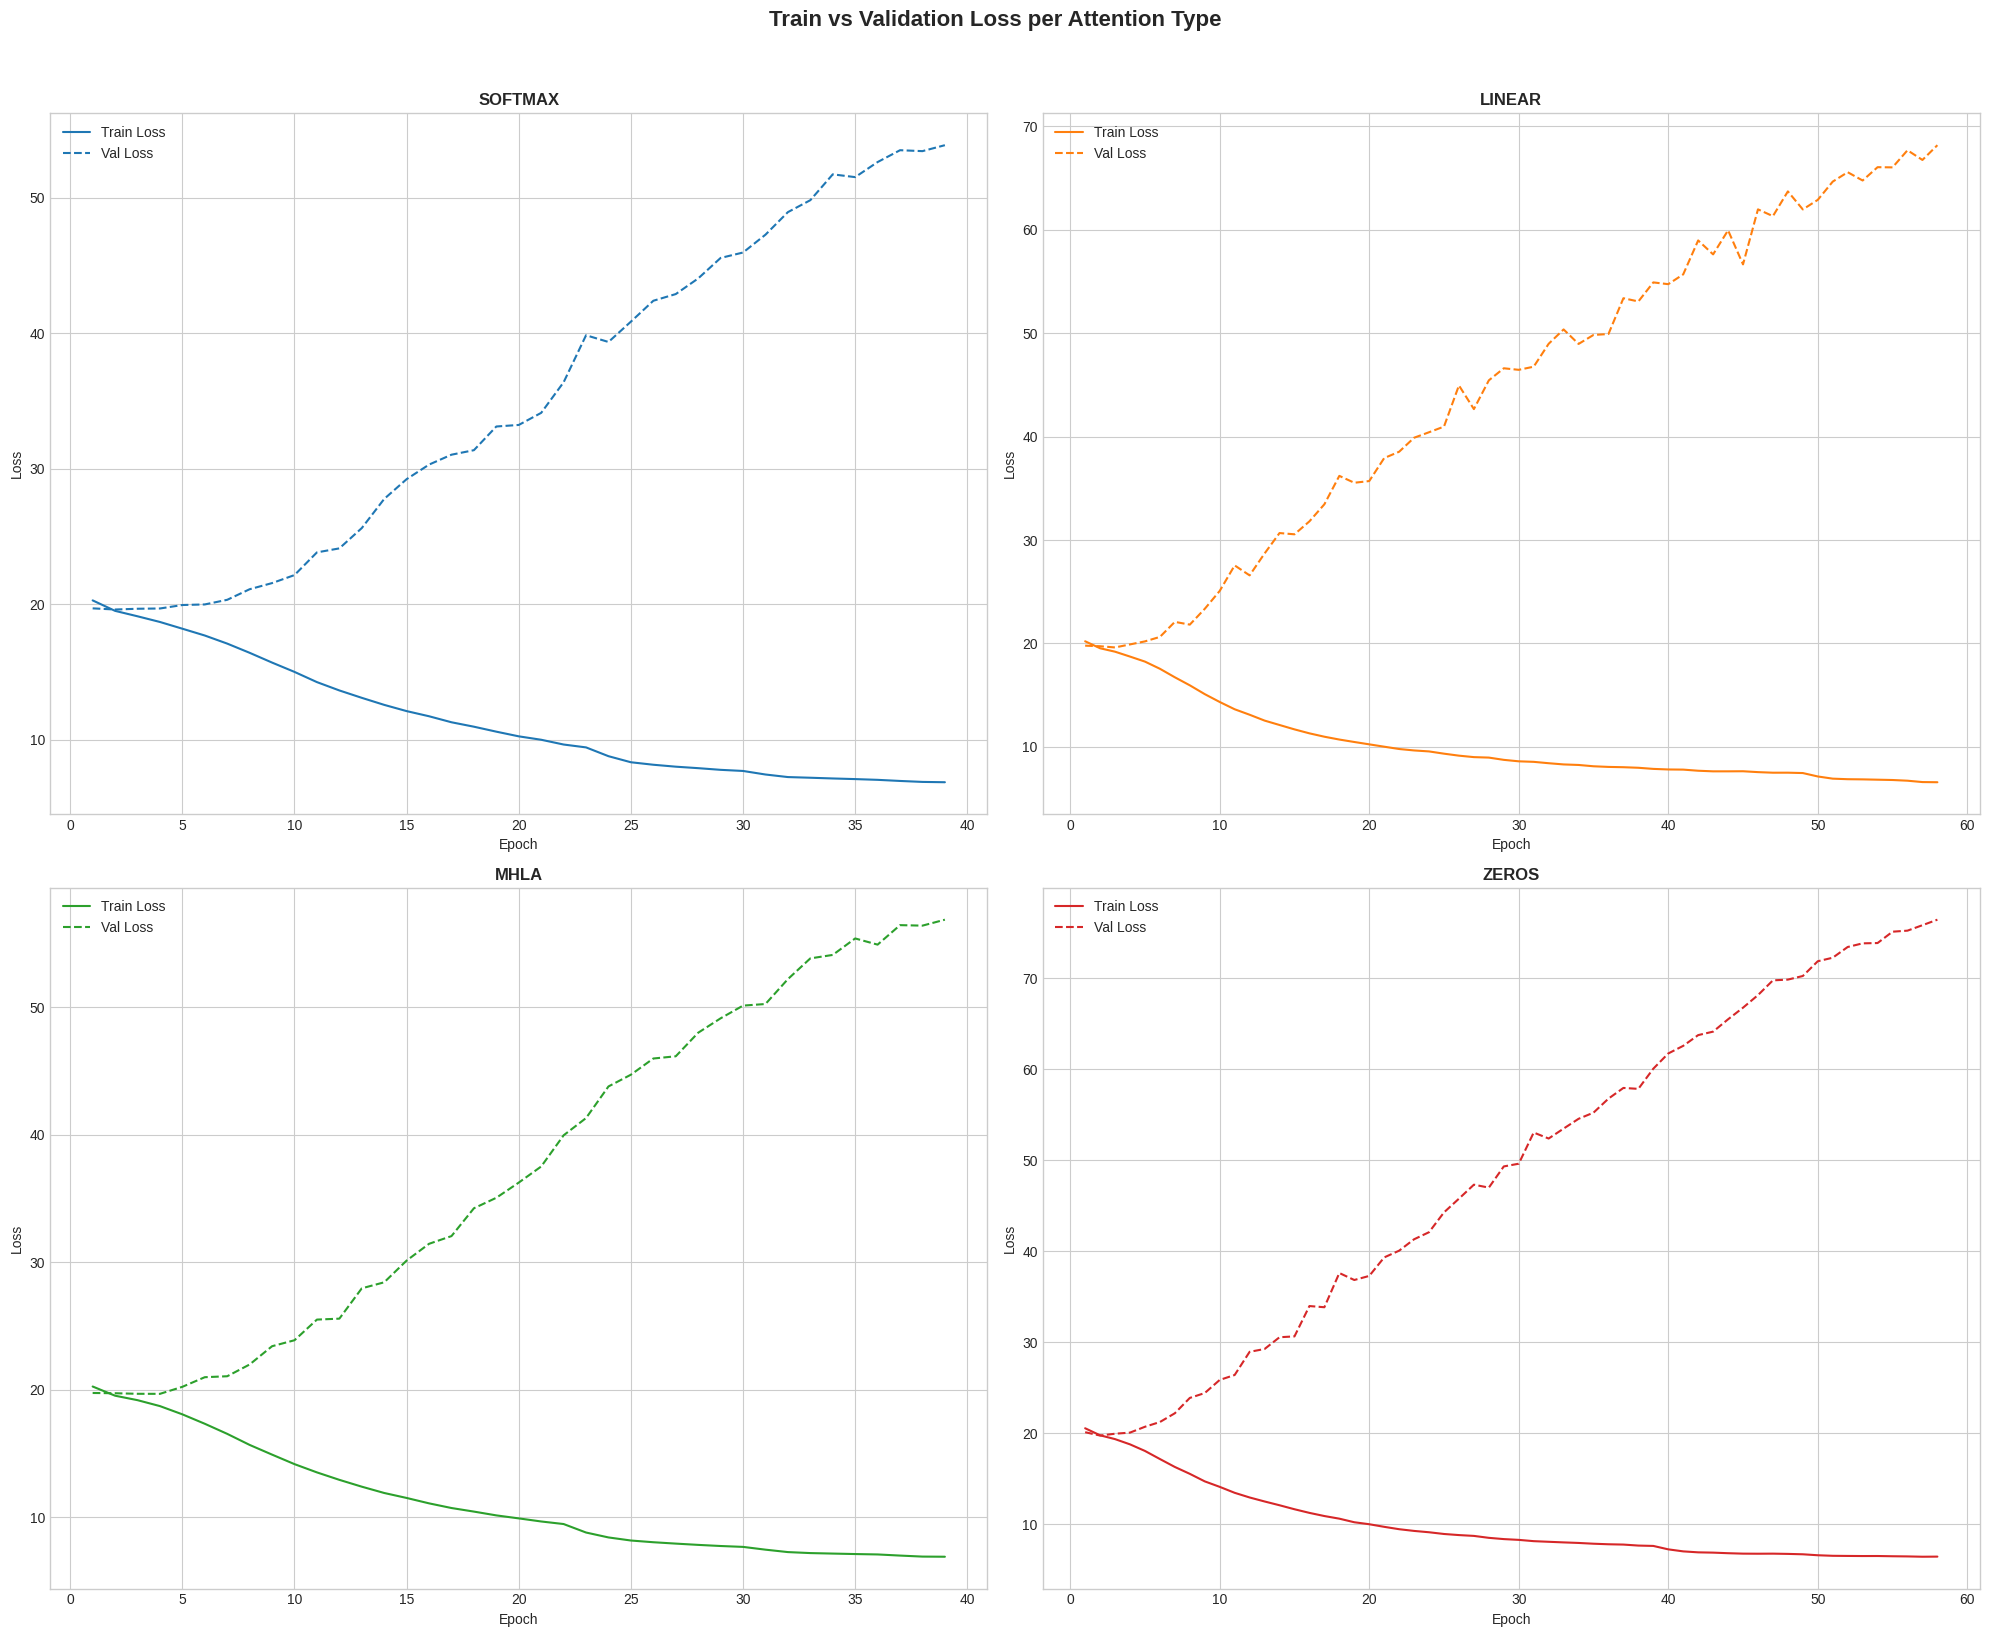

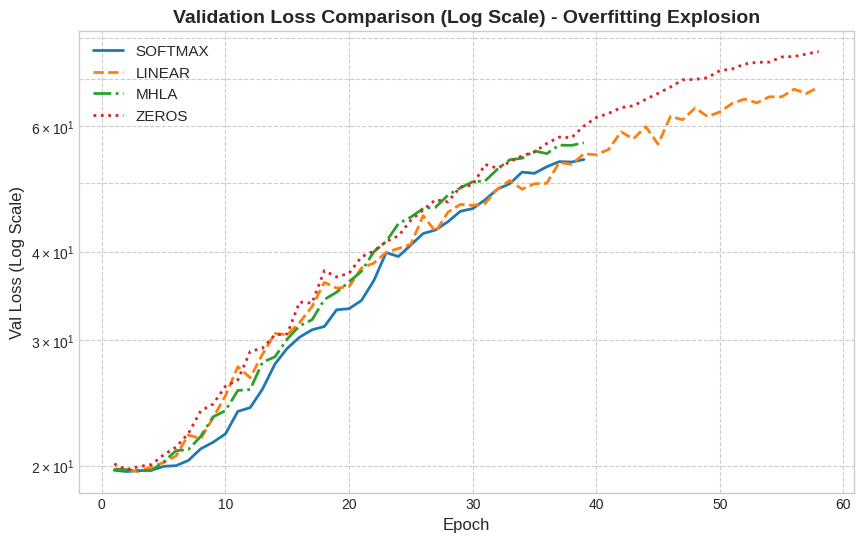

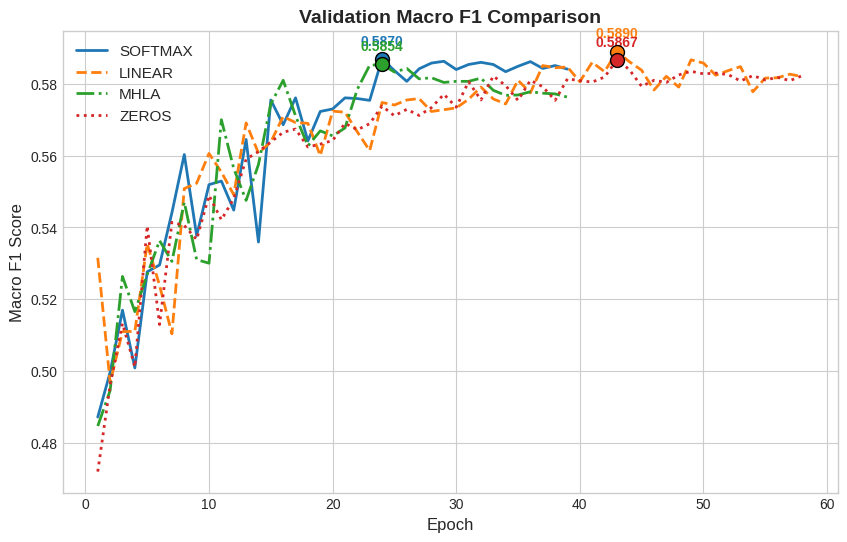

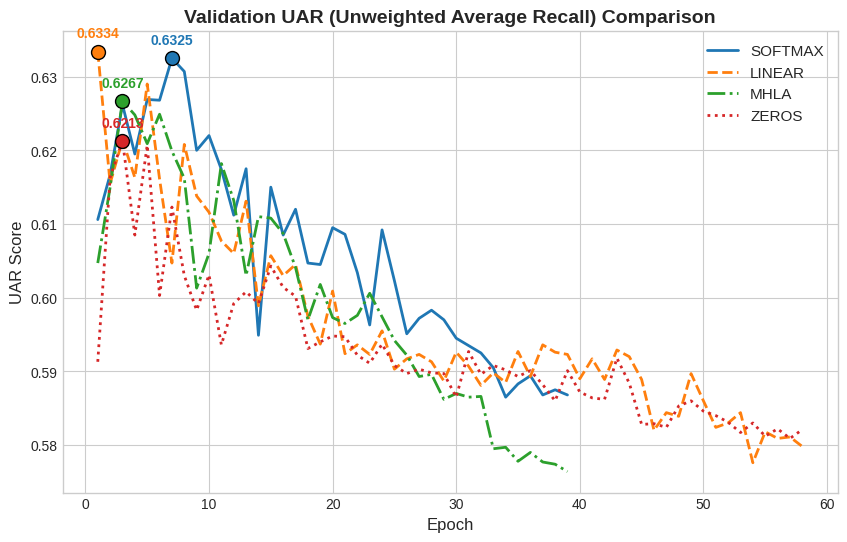

In [34]:
data = {}
current_attn = None

# Регулярные выражения для поиска
attn_pattern = re.compile(r"Training with: (\w+)")
epoch_pattern = re.compile(r"Epoch (\d+)/\d+ \| Time: .*? \| Train Loss: ([\d.]+) \| Val Loss: ([\d.]+) \| Val F1: ([\d.]+) \| Val UAR: ([\d.]+)")

for line in log_text.split('\n'):
    attn_match = attn_pattern.search(line)
    if attn_match:
        current_attn = attn_match.group(1)
        data[current_attn] = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_uar': []}
        continue

    if current_attn:
        epoch_match = epoch_pattern.search(line)
        if epoch_match:
            epoch, t_loss, v_loss, v_f1, v_uar = epoch_match.groups()
            data[current_attn]['epoch'].append(int(epoch))
            data[current_attn]['train_loss'].append(float(t_loss))
            data[current_attn]['val_loss'].append(float(v_loss))
            data[current_attn]['val_f1'].append(float(v_f1))
            data[current_attn]['val_uar'].append(float(v_uar))

# Цвета и стили для графиков
colors = {'softmax': '#1f77b4', 'linear': '#ff7f0e', 'mhla': '#2ca02c', 'zeros': '#d62728'}
styles = {'softmax': '-', 'linear': '--', 'mhla': '-.', 'zeros': ':'}

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 16))

# ------------------------------------------
# График 1: Train vs Val Loss для каждой модели (2x2 сетка)
# ------------------------------------------
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_title('Overfitting Dynamics: Train vs Val Loss', fontsize=14, fontweight='bold')

for i, (name, metrics) in enumerate(data.items()):
    ax_sub = fig.add_subplot(2, 2, i + 1)
    ax_sub.plot(metrics['epoch'], metrics['train_loss'], label='Train Loss', color=colors[name], linestyle='-')
    ax_sub.plot(metrics['epoch'], metrics['val_loss'], label='Val Loss', color=colors[name], linestyle='--')
    ax_sub.set_title(f'{name.upper()}', fontsize=12, fontweight='bold')
    ax_sub.set_xlabel('Epoch')
    ax_sub.set_ylabel('Loss')
    ax_sub.legend()
    ax_sub.grid(True)

fig.delaxes(ax1)
fig.suptitle('Train vs Validation Loss per Attention Type', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# ------------------------------------------
# График 2: Сравнение Val Loss (Log Scale)
# ------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 6))

for name, metrics in data.items():
    ax2.plot(metrics['epoch'], metrics['val_loss'], label=name.upper(), color=colors[name], linestyle=styles[name], linewidth=2)

ax2.set_title('Validation Loss Comparison (Log Scale) - Overfitting Explosion', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Val Loss (Log Scale)', fontsize=12)
ax2.set_yscale('log')
ax2.legend(fontsize=11)
ax2.grid(True, which="both", ls="--")

# ------------------------------------------
# График 3: Сравнение Val F1
# ------------------------------------------
fig3, ax3 = plt.subplots(figsize=(10, 6))

for name, metrics in data.items():
    ax3.plot(metrics['epoch'], metrics['val_f1'], label=name.upper(), color=colors[name], linestyle=styles[name], linewidth=2)
    # Находим и отмечаем лучшую эпоху
    best_idx = np.argmax(metrics['val_f1'])
    best_f1 = metrics['val_f1'][best_idx]
    best_epoch = metrics['epoch'][best_idx]
    ax3.scatter(best_epoch, best_f1, color=colors[name], s=100, zorder=5, edgecolors='black')
    ax3.annotate(f'{best_f1:.4f}', (best_epoch, best_f1), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color=colors[name])

ax3.set_title('Validation Macro F1 Comparison', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Macro F1 Score', fontsize=12)
ax3.legend(fontsize=11)
ax3.grid(True)

# ------------------------------------------
# График 4: Сравнение Val UAR
# ------------------------------------------
fig4, ax4 = plt.subplots(figsize=(10, 6))

for name, metrics in data.items():
    ax4.plot(metrics['epoch'], metrics['val_uar'], label=name.upper(), color=colors[name], linestyle=styles[name], linewidth=2)
    best_idx = np.argmax(metrics['val_uar'])
    best_uar = metrics['val_uar'][best_idx]
    best_epoch = metrics['epoch'][best_idx]
    ax4.scatter(best_epoch, best_uar, color=colors[name], s=100, zorder=5, edgecolors='black')
    ax4.annotate(f'{best_uar:.4f}', (best_epoch, best_uar), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color=colors[name])

ax4.set_title('Validation UAR (Unweighted Average Recall) Comparison', fontsize=14, fontweight='bold')
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('UAR Score', fontsize=12)
ax4.legend(fontsize=11)
ax4.grid(True)

plt.show()

Все четыре механизма внимания демонстрируют крайне сильное переобучение, которое наступает очень рано (уже после 4-5 эпох).

Расхождение: Train Loss падает с ~20 до ~6.5-7.0, в то время как Val Loss после небольшого спада в первые эпохи начинает неуклонно расти, достигая астрономических значений (53 у Softmax, 68 у Linear, 76 у ZeroS).

Сравнение качества: Ничья.  
С точки зрения главных метрик (Best Val F1 и Best Val UAR), все четыре механизма показали практически одинаковый результат:

Best F1: от 0.5854 (MHLA) до 0.5890 (Linear). Разница в 0.003 статистически незначима.
Best UAR: от 0.6213 (ZeroS) до 0.6334 (Linear). Softmax и Linear чуть лучше справляются с балансом классов.  
Вывод: На данном датасете и при текущих гиперпараметрах выбор механизма внимания не влияет на предельную способность модели решать задачу.


Сравнение эффективности: ZeroS и MHLA провалили тест на скорость.  
На коротких последовательностях линейные внимания не дают преимущества, а лишь добавляют накладные расходы:

Softmax (Базлайн): ~23.5 сек/эпоха, 184.9 MB VRAM. Быстро и дешево.   
Linear: ~24.5 сек/эпоха, 221.1 MB VRAM. Чуть медленнее из-за einsum, но сравнимо.   
MHLA: ~28.5 сек/эпоха, 499.8 MB VRAM. Медленнее Softmax на 20% и ест в 2.5 раза больше памяти из-за хранения матриц смешивания и разбиения на блоки. На коротких
N не окупает себя.  
ZeroS: ~77.7 сек/эпоха (в 3.3 раза медленнее!), 2765.7 MB VRAM (в 15 раз больше!). Абсолютный аутсайдер по эффективности. Чистая PyTorch-реализация ZeroS с префиксными суммами (prefix scans) и огромным количеством Gate-слоев крайне неэффективна на малых N по сравнению с оптимизированным F.scaled_dot_product_attention внутри Softmax.

